In [1]:
# PaySim is 63L rows — so we sample 5L for speed
import pandas as pd
import numpy as np

print("Loading PaySim dataset...")
paysim = pd.read_csv(
    r'D:\Major Project\DATASETS MAJOR PROJECT\paysim dataset.csv\paysim dataset.csv',
    nrows=500000  # 5 lakh rows — laptop కి enough
)

print("Shape:", paysim.shape)
print("Columns:", list(paysim.columns))
print("\nFraud distribution:")
print(paysim['isFraud'].value_counts())
print(paysim.head(3))

Loading PaySim dataset...
Shape: (500000, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Fraud distribution:
isFraud
0    499767
1       233
Name: count, dtype: int64
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  


In [2]:
# Drop name columns — not useful
paysim = paysim.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# Encode transaction type (PAYMENT, TRANSFER, etc.)
paysim['type'] = paysim['type'].map({
    'PAYMENT': 0, 'TRANSFER': 1,
    'CASH_OUT': 2, 'DEBIT': 3, 'CASH_IN': 4
})

# New features — balance difference (fraud indicator!)
paysim['orig_balance_diff'] = paysim['oldbalanceOrg'] - paysim['newbalanceOrig'] - paysim['amount']
paysim['dest_balance_diff'] = paysim['newbalanceDest'] - paysim['oldbalanceDest'] - paysim['amount']

# Zero balance flags
paysim['orig_zero'] = (paysim['newbalanceOrig'] == 0).astype(int)
paysim['dest_zero'] = (paysim['oldbalanceDest'] == 0).astype(int)

print("Features ready!")
print(paysim.shape)
print(paysim.head(3))

Features ready!
(500000, 12)
   step  type   amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     0  9839.64       170136.0       160296.36             0.0   
1     1     0  1864.28        21249.0        19384.72             0.0   
2     1     1   181.00          181.0            0.00             0.0   

   newbalanceDest  isFraud  orig_balance_diff  dest_balance_diff  orig_zero  \
0             0.0        0       1.455192e-11           -9839.64          0   
1             0.0        0      -1.136868e-12           -1864.28          0   
2             0.0        1       0.000000e+00            -181.00          1   

   dest_zero  
0          1  
1          1  
2          1  


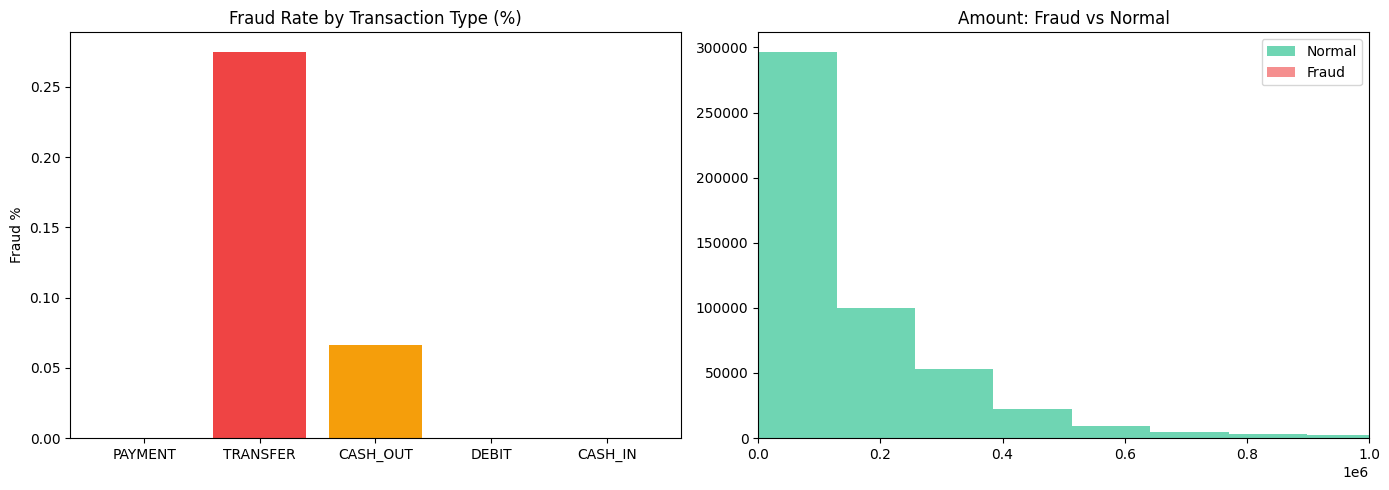

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud by transaction type
fraud_by_type = paysim.groupby('type')['isFraud'].mean() * 100
type_names = ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
axes[0].bar(type_names, fraud_by_type, color=['#3b82f6','#ef4444','#f59e0b','#10b981','#6366f1'])
axes[0].set_title('Fraud Rate by Transaction Type (%)')
axes[0].set_ylabel('Fraud %')

# Amount distribution
axes[1].hist(paysim[paysim['isFraud']==0]['amount'], bins=50, alpha=0.6, label='Normal', color='#10b981')
axes[1].hist(paysim[paysim['isFraud']==1]['amount'], bins=50, alpha=0.6, label='Fraud', color='#ef4444')
axes[1].set_title('Amount: Fraud vs Normal')
axes[1].legend()
axes[1].set_xlim(0, 1000000)

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = paysim.drop('isFraud', axis=1)
y = paysim['isFraud']

# Scale
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE
sm2 = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm2.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
isFraud
0    399814
1    399814
Name: count, dtype: int64


Training XGBoost on PaySim...

=== XGBoost — PaySim Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99953
           1       0.29      0.87      0.44        47

    accuracy                           1.00    100000
   macro avg       0.65      0.94      0.72    100000
weighted avg       1.00      1.00      1.00    100000

ROC AUC: 0.9633


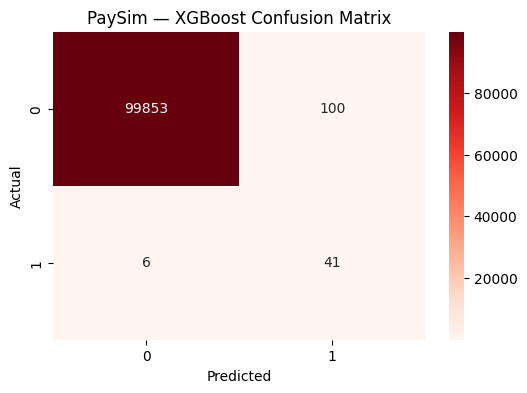

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Training XGBoost on PaySim...")

xgb_paysim = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_paysim.fit(X_train_sm, y_train_sm)

y_pred = xgb_paysim.predict(X_test)

print("\n=== XGBoost — PaySim Results ===")
print(classification_report(y_test, y_pred))
print("ROC AUC:", round(roc_auc_score(y_test, xgb_paysim.predict_proba(X_test)[:,1]), 4))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("PaySim — XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
import pickle

pickle.dump(xgb_paysim, open(r'D:\Major Project\model\paysim_xgb_model.pkl', 'wb'))
pickle.dump(scaler2, open(r'D:\Major Project\model\paysim_scaler.pkl', 'wb'))

print("✅ PaySim model saved!")

✅ PaySim model saved!


   MULTIMODAL FINTECH — All Models Summary
               Model  Accuracy  F1 Score  ROC AUC
     RF (CreditCard)  0.999456  0.841026 0.973103
XGBoost (CreditCard)  0.999245  0.801843 0.979159
    XGBoost (PaySim)  0.998940  0.436170 0.963336


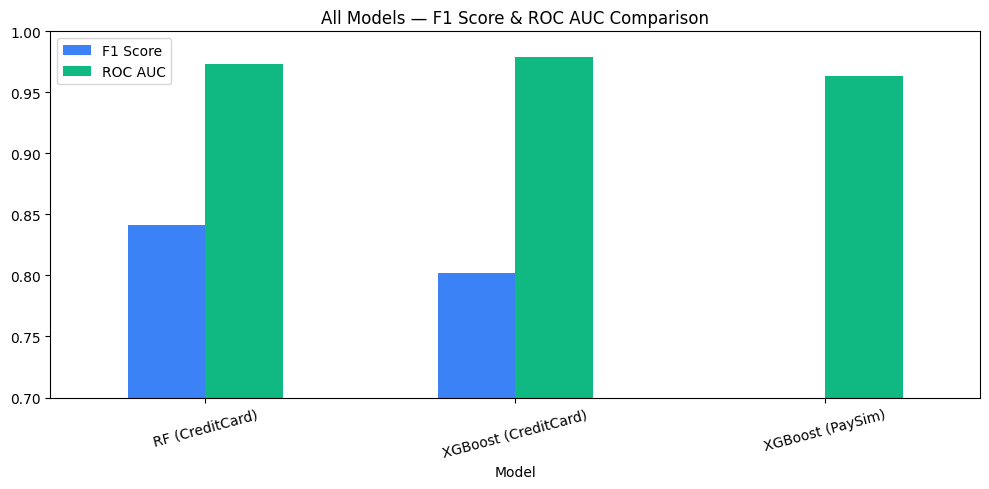

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# PaySim results
pay_acc = accuracy_score(y_test, y_pred)
pay_f1  = f1_score(y_test, y_pred)
pay_auc = roc_auc_score(y_test, xgb_paysim.predict_proba(X_test)[:,1])

# Full comparison table
final_results = pd.DataFrame({
    'Model': ['RF (CreditCard)', 'XGBoost (CreditCard)', 'XGBoost (PaySim)'],
    'Accuracy': [0.999456, 0.999245, pay_acc],
    'F1 Score': [0.841026, 0.801843, pay_f1],
    'ROC AUC':  [0.973103, 0.979159, pay_auc]
})

print("=" * 55)
print("   MULTIMODAL FINTECH — All Models Summary")
print("=" * 55)
print(final_results.to_string(index=False))

# Bar chart
final_results.set_index('Model')[['F1 Score','ROC AUC']].plot(
    kind='bar', figsize=(10,5), color=['#3b82f6','#10b981']
)
plt.title("All Models — F1 Score & ROC AUC Comparison")
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [8]:
# Reload — TRANSFER & CASH_OUT only (fraud only happens here!)
print("Loading full PaySim — filtered...")
paysim_full = pd.read_csv(
    r'D:\Major Project\DATASETS MAJOR PROJECT\paysim dataset.csv\paysim dataset.csv'
)

# Filter only fraud-relevant types
paysim_filtered = paysim_full[
    paysim_full['type'].isin(['TRANSFER', 'CASH_OUT'])
].copy()

print("Filtered shape:", paysim_filtered.shape)
print("Fraud cases:", paysim_filtered['isFraud'].sum())
print("Fraud %:", round(paysim_filtered['isFraud'].mean()*100, 3), "%")

Loading full PaySim — filtered...
Filtered shape: (2770409, 11)
Fraud cases: 8213
Fraud %: 0.296 %


In [9]:
paysim_filtered = paysim_filtered.drop(['nameOrig','nameDest','isFlaggedFraud'], axis=1)

# Encode type
paysim_filtered['type'] = paysim_filtered['type'].map({'TRANSFER': 1, 'CASH_OUT': 2})

# Strong fraud indicators
paysim_filtered['orig_balance_diff'] = (
    paysim_filtered['oldbalanceOrg'] - paysim_filtered['newbalanceOrig'] - paysim_filtered['amount']
)
paysim_filtered['dest_balance_diff'] = (
    paysim_filtered['newbalanceDest'] - paysim_filtered['oldbalanceDest'] - paysim_filtered['amount']
)
paysim_filtered['orig_zero']     = (paysim_filtered['newbalanceOrig'] == 0).astype(int)
paysim_filtered['dest_zero']     = (paysim_filtered['oldbalanceDest'] == 0).astype(int)
paysim_filtered['amount_ratio']  = paysim_filtered['amount'] / (paysim_filtered['oldbalanceOrg'] + 1)

print("Features ready:", list(paysim_filtered.columns))

Features ready: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'amount_ratio']


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

X2 = paysim_filtered.drop('isFraud', axis=1)
y2 = paysim_filtered['isFraud']

scaler3 = StandardScaler()
X2_scaled = scaler3.fit_transform(X2)

X_tr, X_te, y_tr, y_te = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

sm3 = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm3.fit_resample(X_tr, y_tr)

print("Training improved PaySim model...")
xgb2 = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb2.fit(X_tr_sm, y_tr_sm)

y_pred2 = xgb2.predict(X_te)
print("\n=== Improved PaySim Model ===")
print(classification_report(y_te, y_pred2))
print("ROC AUC:", round(roc_auc_score(y_te, xgb2.predict_proba(X_te)[:,1]), 4))

Training improved PaySim model...

=== Improved PaySim Model ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.97      1.00      0.99      1643

    accuracy                           1.00    554082
   macro avg       0.99      1.00      0.99    554082
weighted avg       1.00      1.00      1.00    554082

ROC AUC: 0.9991


In [11]:
from sklearn.metrics import accuracy_score, f1_score

pay2_acc = accuracy_score(y_te, y_pred2)
pay2_f1  = f1_score(y_te, y_pred2)
pay2_auc = roc_auc_score(y_te, xgb2.predict_proba(X_te)[:,1])

final = pd.DataFrame({
    'Model': [
        'RF — CreditCard',
        'XGBoost — CreditCard',
        'XGBoost — PaySim v1',
        'XGBoost — PaySim v2 (Improved)'
    ],
    'Accuracy': [0.999456, 0.999245, 0.998940, pay2_acc],
    'F1 Score': [0.841026, 0.801843, 0.436170, pay2_f1],
    'ROC AUC':  [0.973103, 0.979159, 0.963336, pay2_auc]
})

print("=" * 65)
print("   MULTIMODAL FINTECH — Final Models Summary")
print("=" * 65)
print(final.to_string(index=False))

# Save improved model
import pickle
pickle.dump(xgb2, open(r'D:\Major Project\model\paysim_xgb_v2.pkl', 'wb'))
pickle.dump(scaler3, open(r'D:\Major Project\model\paysim_scaler_v2.pkl', 'wb'))
print("\n✅ Improved model saved!")

   MULTIMODAL FINTECH — Final Models Summary
                         Model  Accuracy  F1 Score  ROC AUC
               RF — CreditCard  0.999456  0.841026 0.973103
          XGBoost — CreditCard  0.999245  0.801843 0.979159
           XGBoost — PaySim v1  0.998940  0.436170 0.963336
XGBoost — PaySim v2 (Improved)  0.999913  0.985560 0.999122

✅ Improved model saved!


In [13]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Step 1: Load saved LSTM model ──
model_lstm = load_model(r'D:\Major Project\model\lstm_model.h5')
print("✅ LSTM model loaded!")

# ── Step 2: Reload CreditCard dataset ──
print("Loading CreditCard dataset...")
df = pd.read_csv(r'D:\Major Project\DATASETS MAJOR PROJECT\creditcard.csv\creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

# ── Step 3: Scale same as before ──
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time']   = scaler.fit_transform(X[['Time']])

# ── Step 4: Split same as before ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Step 5: Reshape for LSTM ──
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("✅ Data ready!")
print("X_test_lstm shape:", X_test_lstm.shape)

✅ LSTM model loaded!
Loading CreditCard dataset...
✅ Data ready!
X_test_lstm shape: (56962, 1, 30)


In [14]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

y_pred_lstm_prob = model_lstm.predict(X_test_lstm)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print("=== LSTM — CreditCard Results ===")
print(classification_report(y_test, y_pred_lstm))
print("ROC AUC:", round(roc_auc_score(y_test, y_pred_lstm_prob), 4))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
=== LSTM — CreditCard Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9727


   MULTIMODAL FINTECH — All Models Final Summary
               Model  Accuracy  F1 Score  ROC AUC
     RF — CreditCard  0.999456  0.841026 0.973103
XGBoost — CreditCard  0.999245  0.801843 0.979159
   LSTM — CreditCard  0.998789  0.713693 0.972704
 XGBoost — PaySim v2  0.999913  0.985560 0.999122


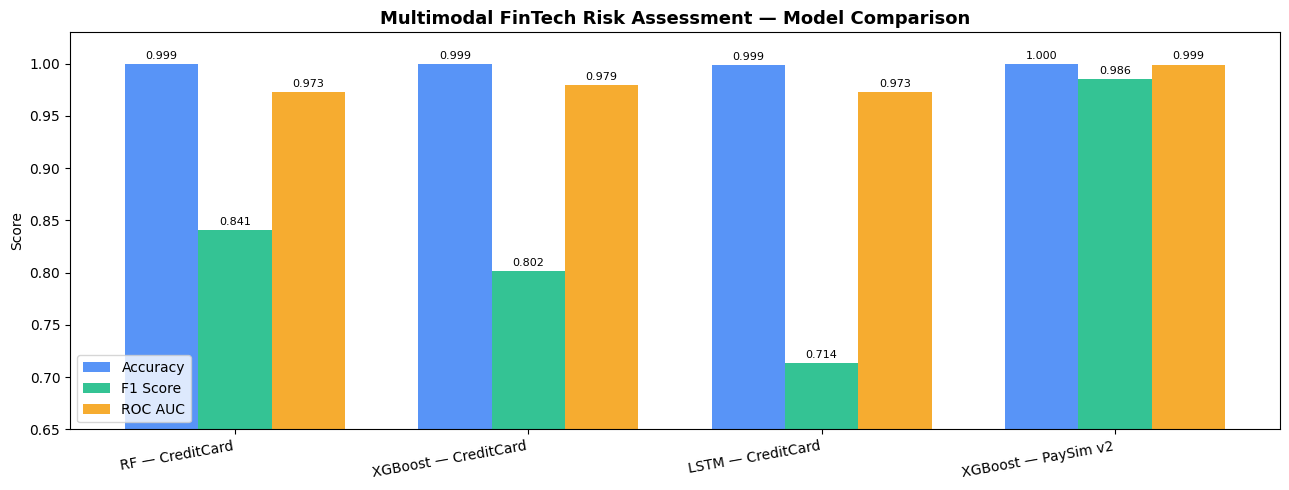

✅ Chart saved!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_f1  = f1_score(y_test, y_pred_lstm)
lstm_auc = roc_auc_score(y_test, y_pred_lstm_prob)

final_all = pd.DataFrame({
    'Model':    ['RF — CreditCard', 'XGBoost — CreditCard',
                 'LSTM — CreditCard', 'XGBoost — PaySim v2'],
    'Accuracy': [0.999456, 0.999245, lstm_acc,  0.999913],
    'F1 Score': [0.841026, 0.801843, lstm_f1,   0.985560],
    'ROC AUC':  [0.973103, 0.979159, lstm_auc,  0.999122]
})

print("=" * 65)
print("   MULTIMODAL FINTECH — All Models Final Summary")
print("=" * 65)
print(final_all.to_string(index=False))

# Bar Chart
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(final_all))
w = 0.25

b1 = ax.bar(x-w, final_all['Accuracy'], w, label='Accuracy',
            color='#3b82f6', alpha=0.85)
b2 = ax.bar(x,   final_all['F1 Score'], w, label='F1 Score',
            color='#10b981', alpha=0.85)
b3 = ax.bar(x+w, final_all['ROC AUC'],  w, label='ROC AUC',
            color='#f59e0b', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(final_all['Model'], rotation=10, ha='right', fontsize=10)
ax.set_ylim(0.65, 1.03)
ax.set_title("Multimodal FinTech Risk Assessment — Model Comparison",
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylabel("Score")

for bars in [b1, b2, b3]:
    for rect in bars:
        h = rect.get_height()
        ax.text(rect.get_x()+rect.get_width()/2., h+0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(r'D:\Major Project\model\model_comparison.png', dpi=150)
plt.show()
print("✅ Chart saved!")